# Full Graph

In the previous notebook, we build an a workflow with clear explicit steps.   

In this notebook, we will convert the previous flows as tool and create a react agent 

## Imports

In [1]:
import sys 
sys.path.insert(0,"../code")

In [14]:
import utils_display
import prompts
import utils
from utils_import import *
from langchain_core.messages import HumanMessage, SystemMessage
import tools
import rich

In [3]:
from pydantic import BaseModel, Field
from typing import Sequence, Optional, Literal
from langchain_core.messages import BaseMessage

from typing_extensions import Annotated, Sequence
from langchain_core.messages import filter_messages

import operator
from langgraph.types import Command
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, get_buffer_string
from langgraph.graph import StateGraph, START, END


## State

In [4]:

class AgentState(BaseModel):
    """
    State for the research agent scoping workflow.
    """

    # Research brief generated from user conversation history
    research_brief: Optional[str] = None
    # messages exchanged in the conversation
    messages: Annotated[Sequence[BaseMessage], operator.add] = []
    notes:str = ""
    final_report: str = ""


class WorkerAgentState(BaseModel):
    research_brief: Optional[str] = None
    messages: Annotated[Sequence[BaseMessage], operator.add] = []




In [5]:
class ClarifyWithUserOutput(BaseModel):
    """Schema for user clarification decision and questions."""
    
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )


class ResearchQuestionOutput(BaseModel):
    """Schema for structured research brief generation."""
    
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

In [6]:
## Scoping methods

In [7]:
model = ChatOpenAI(
        model="gpt-4.1",
        base_url=OPENAI_BASE_URL,
        temperature=0.0,
        #max_tokens=512,
)

In [39]:
def clarify_with_user(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:
    """
    Determine if the user's request contains sufficient information to proceed with research, or if a clarifying question is needed.
    """

    
    # Set up structured output model
    structured_output_model = model.with_structured_output(ClarifyWithUserOutput)

    # Invoke the model with clarification instructions
    response = structured_output_model.invoke([
        HumanMessage(content=prompts.clarify_with_user_instructions.format(
            messages=get_buffer_string(messages=state.messages), 
            date=utils.get_today_str()
        ))
    ])
    
    # Route based on clarification need
    if response.need_clarification:
        return Command(
            goto=END, 
            update={"messages": [AIMessage(content=response.question)]}
        )
    else:
        return Command(
            goto="write_research_brief", 
            update={"messages": [AIMessage(content=response.verification)]}
        )

def write_research_brief(state: AgentState):
    """
    Transform the conversation history into a comprehensive research brief.
    """
    # Set up structured output model
    structured_output_model = model.with_structured_output(ResearchQuestionOutput)
    
    # Generate research brief from conversation history
    response = structured_output_model.invoke([
        HumanMessage(content=prompts.transform_messages_into_research_topic.format(
            messages=get_buffer_string(state.messages),
            date=utils.get_today_str()
        ))
    ])
    
    return {
        "research_brief": response.research_brief,
        "messages": [HumanMessage(content=f"{response.research_brief}.")]
    }



def research(state: AgentState):
    llm_tools = [tools.web_search_tool, tools.think_tool, tools.summarize_findings_tool]
    llm = ChatOpenAI(
        model="gpt-4o",
        base_url=OPENAI_BASE_URL,
        temperature=0.7
    )
    system_message = prompts.agent_system_prompt.format(date=utils.get_today_str())
    research_agent = create_agent(
        llm,                          # The LLM to use
        llm_tools,                        # List of tools
        system_prompt=system_message # System prompt
    )


    state_research = WorkerAgentState (research_brief=state.research_brief, messages= [HumanMessage(content= state.research_brief)] )

    state_research = research_agent.invoke(state_research)

    notes = utils.extract_research_notes(state_research['messages'])

    return {"notes": notes , "messages": [AIMessage(content=f"Worker done researching. Notes {notes}")]}


# def final_report_generation(state: AgentState):
#     """
#     Final report generation node.

#     Synthesizes all research findings into a comprehensive final report
#     """

#     writer_model = ChatOpenAI(
#         model="gpt-4.1",
#         base_url=OPENAI_BASE_URL,
#         max_tokens=32000
#     ) 
    
#     # Pull the aggregated research notes captured by previous steps
#     notes = state.notes


#     final_report_prompt = prompts.final_report_generation.format(
#         research_brief=state.research_brief,
#         findings=notes,
#         date=utils.get_today_str()
#     )

#     # Use the writer model to generate the final report
#     final_report = writer_model.invoke([HumanMessage(content=final_report_prompt)])

#     return {
#         "final_report": final_report.content, 
#     }



def extract_research_notes(messages:list):
    """
    Extract research notes from the conversation messages.
    Filters messages to include only those generated by tools or the AI.
    """

    raw_notes = [
            str(m.content) for m in filter_messages(
                messages, 
                include_types=["tool", "ai"]
            )
        ]
    return "\n".join(raw_notes)


def final_report_generation(state: AgentState):
    """
    Final report generation node.

    Synthesizes all research findings into a comprehensive final report
    """

    writer_model = ChatOpenAI(
        model="gpt-4.1",
        base_url=OPENAI_BASE_URL,
        max_tokens=32000
    ) 

    # Pull the aggregated research notes captured by previous steps
    notes = extract_research_notes(state.messages)


    final_report_prompt = prompts.final_report_generation.format(
        research_brief=state.research_brief,
        findings=notes,
        date=utils.get_today_str()
    )

    # Use the writer model to generate the final report
    final_report = writer_model.invoke([HumanMessage(content=final_report_prompt)])

    return {
        "final_report": final_report.content, 
         "messages": [AIMessage(content=f" Generated final report. {final_report.content}")]
    }


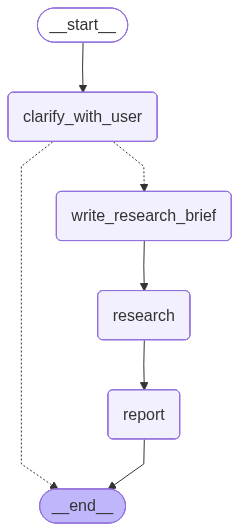

In [40]:
graph_builder = StateGraph(AgentState)

# Add workflow nodes
graph_builder.add_node("clarify_with_user", clarify_with_user)
graph_builder.add_node("write_research_brief", write_research_brief)
graph_builder.add_node("research", research)
graph_builder.add_node("report", final_report_generation)

# add edges
graph_builder.add_edge(START, "clarify_with_user") 
graph_builder.add_edge("write_research_brief", "research") 
graph_builder.add_edge("research", "report") 
graph_builder.add_edge("report", END)


# Compile the full workflow
graph = graph_builder.compile()
graph

In [41]:
query = "What is the best coffee shop in seattle."

In [42]:
result = graph.invoke({"messages": [HumanMessage(content=query)]})


In [43]:
utils_display.format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is the best coffee shop in seattle.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere,      │
│ popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a  │
│ whole?                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [44]:
human_answer = "Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me."
result["messages"] += [HumanMessage(content=human_answer)]
result = graph.invoke(result)



💭 Thinking: To find the best coffee shop in Seattle, we'll need to gather information on several key aspects:

1...
🔍 Searching: best coffee shops in Seattle 2025 quality beans atmosphere
🔍 Searching: best coffee shops in Seattle 2025 quality beans atmosphere
💭 Thinking: From the search results, I have gathered relevant information on the top coffee shops in Seattle foc...
🔍 Searching: Seattle coffee shop reviews 2025 Storyville, Olympia, Starbucks Reserve, Onda Origins
🔍 Searching: Seattle coffee shop reviews 2025 Storyville, Olympia, Starbucks Reserve, Onda Origins
💭 Thinking: The additional search results provide insight into specific coffee shops within Seattle, focusing on...
📝 Summarizing 1798 chars of findings


In [45]:
result

{'research_brief': 'I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee bean and the atmosphere of the shop. The focus should be on establishments within the city of Seattle as a whole. Open considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, modern, lively), and whether other factors such as food offerings or price should be considered.',
 'messages': [HumanMessage(content='What is the best coffee shop in seattle.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere, popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a whole?", additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me.', additional_kwargs={}, response_met

In [46]:
from rich.markdown import Markdown

Markdown(result['final_report'])

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃              The Best Coffee Shops in Seattle (2025): Focus on Coffee Bean Quality and Atmosphere               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

Seattle, renowned for its rich coffee culture and as the birthplace of several coffee innovations, boasts a diverse
selection of coffee shops ranging from cozy local spots to immersive retail experiences. This report identifies    
leading coffee shops within the city by prioritizing the quality of their coffee beans and the atmosphere of their 
establishments. The evaluation draws on multiple recent guides and reviews, ensuring balanced coverage across      
firsthand experiences and expert curation.                                                                         


                                              Criteria for Selection                                               

Two primary criteria informed this assessment:                                                                     

 • Quality of Coffee Beans: Shops and roasters known for exceptional sourcing, flavor, and ethical practices.      
 • Atmosphere: Environments that enhance the coffee experience, whether through design, ambiance, or service.      


                                 Top Contenders: Seattle’s Exemplary Coffee Shops                                  

                                             Storyville Coffee Company                                             

Located in Pike Place Market, Storyville Coffee Company consistently ranks among Seattle's finest coffee           
destinations. It garners a notable 4.5/5 rating from over 2,500 reviewers, signaling both enduring popularity and  
high customer satisfaction. The shop is described as providing "expensive coffee vibes," reflecting not only       
premium pricing but also a luxurious ambiance and attention to detail in its offerings. The central location makes 
it a popular stop for tourists wishing to experience Seattle's coffee tradition in a bustling, historic setting.   
While prices may be higher relative to some competitors, the ambiance and quality are considered commensurate by   
many patrons ]8;id=731077;https://www.yelp.com/search?find_desc=Coffee+Roasters&find_loc=Seattle%2C+WA\TOP 10 BEST Coffee Roasters in Seattle, WA - Updated 2025 - Yelp]8;;\, ]8;id=448061;https://www.yelp.com/biz/storyville-coffee-company-seattle-9\STORYVILLE COFFEE COMPANY - Updated ]8;;\
]8;id=448061;https://www.yelp.com/biz/storyville-coffee-company-seattle-9\November 2025 - Yelp]8;;\.                                                                                              

                                            Starbucks Reserve Roastery                                             

Central Seattle is home to the flagship Starbucks Reserve Roastery, which offers an immersive, upscale coffee      
experience beyond the standard café format. It stands out for its rare brews, on-site roasting demonstrations, and 
comprehensive service—features that attract both casual visitors and coffee aficionados. Service levels are        
routinely described as "exceptional," with knowledgeable and attentive staff who contribute significantly to the   
shop's reputation. Additionally, the Roastery functions as a significant tourist attraction, enhancing the overall 
ambiance and making it a destination in itself rather than just a place to get coffee ]8;id=866554;https://www.junky-traveler.com/post/seattle-coffee-guide-2025-the-best-cafes-for-work-tourists-instagram-lovers\Seattle Coffee Guide 2025: ]8;;\  
]8;id=866554;https://www.junky-traveler.com/post/seattle-coffee-guide-2025-the-best-cafes-for-work-tourists-instagram-lovers\The Best Cafes for Work, Tourists ...]8;;\, ]8;id=608622;https://www.tripadvisor.com/Attraction_

In [47]:
utils_display.format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is the best coffee shop in seattle.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere,      │
│ popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a  │
│ whole?                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me.            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for clarifying your priorities: quality of the coffee bean and the atmosphere of the shop. I have     │
│ enough information to begin researching the best coffee shops in Seattle based on these criteria.               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee bean and the           │
│ atmosphere of the shop. The focus should be on establishments within the city of Seattle as a whole. Open       │
│ considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, modern, lively), │
│ and whether other factors such as food offerings or price should be considered..                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Worker done researching. Notes                                                                                  │
│ Reasoning recorded: To find the best coffee shop in Seattle, we'll need to gather information on several key    │
│ aspects:                                                                                                        │
│                                                                                                                 │
│ 1. **Quality of Coffee Bean:**                                                                                  │
│    - Which coffee shops are known for their high-quality coffee beans?                                          │
│    - Are there specific brands or sources of beans that are particularly noteworthy?                            │
│                                                                                                                 │
│ 2. **Atmosphere of the Shop:**                                                                                  │
│    - What types of atmospheres do Seattle's coffee shops offer (e.g., cozy, modern, lively)?                    │
│    - How do these atmospheres enhance the coffee-drinking experience?                                           │
│                                                                                                                 │
│ 3. **Specific Neighborhoods:**                                                                                  │
│    - Are there neighborhoods in Seattle known for having a high concentration of excellent coffee shops?        │
│    - How do these neighborhoods compare in terms of coffee culture?                                             │
│                                                                                                                 │
│ 4. **Additional Considerations:**                                                                               │
│    - Should we consider food offerings, price, or other factors like customer service or sustainability?        │
│                                                                                                                 │
│ Given these aspects, I will start by searching for lists or articles that rank or discuss the best coffee shops │
│ in Seattle, focusing on coffee quality and atmosphere. I'll also look for any notable reviews or guides that    │
│ emphasize these criteria. I'll aim to identify a few top contenders and explore what makes them stand out in    │
│ more detail.                                                                                                    │
│                                                                                                                 │
│ Search results for: 'best coffee shops in Seattle 2025 quality beans atmosphere'                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Seattle Coffee Guide 2025: The Best Cafes for Work, Tourists ... ---                              │
│ URL:                                                                                                            │
│ https://www.junky-traveler.com/post/seattle-coffee-guide-2025-the-best-cafes-for-work-tourists-instagram-lovers │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ The webpage features a comprehensive guide to the best coffee shops in Seattle, ideal for work and social media │
│ photography. Highlighting the city's rich coffee cultur

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│  Generated final report. # The Best Coffee Shops in Seattle (2025): Focus on Coffee Bean Quality and Atmosphere │
│                                                                                                                 │
│ Seattle, renowned for its rich coffee culture and as the birthplace of several coffee innovations, boasts a     │
│ diverse selection of coffee shops ranging from cozy local spots to immersive retail experiences. This report    │
│ identifies leading coffee shops within the city by prioritizing the quality of their coffee beans and the       │
│ atmosphere of their establishments. The evaluation draws on multiple recent guides and reviews, ensuring        │
│ balanced coverage across firsthand experiences and expert curation.                                             │
│                                                                                                                 │
│ ## Criteria for Selection                                                                                       │
│                                                                                                                 │
│ Two primary criteria informed this assessment:                                                                  │
│ - **Quality of Coffee Beans:** Shops and roasters known for exceptional sourcing, flavor, and ethical           │
│ practices.                                                                                                      │
│ - **Atmosphere:** Environments that enhance the coffee experience, whether through design, ambiance, or         │
│ service.                                                                                                        │
│                                                                                                                 │
│ ## Top Contenders: Seattle’s Exemplary Coffee Shops                                                             │
│                                                                                                                 │
│ ### Storyville Coffee Company                                                                                   │
│                                                                                                                 │
│ Located in Pike Place Market, Storyville Coffee Company consistently ranks among Seattle's finest coffee        │
│ destinations. It garners a notable 4.5/5 rating from over 2,500 reviewers, signaling both enduring popularity   │
│ and high customer satisfaction. The shop is described as providing "expensive coffee vibes," reflecting not     │
│ only premium pricing but also a luxurious ambiance and attention to detail in its offerings. The central        │
│ location makes it a popular stop for tourists wishing to experience Seattle's coffee tradition in a bustling,   │
│ historic setting. While prices may be higher relative to some competitors, the ambiance and quality are         │
│ considered commensurate by many patrons [TOP 10 BEST Coffee Roasters in Seattle, WA - Updated 2025 -            │
│ Yelp](https://www.yelp.com/search?find_desc=Coffee+Roasters&find_loc=Seattle%2C+WA), [STORYVILLE COFFEE COMPANY │
│ - Updated November 2025 - Yelp](https://www.yelp.com/biz/storyville-coffee-company-seattle-9).                  │
│                                                                                                                 │
│ ### Starbucks Reserve Roastery                                                                                  │
│                                                                                                                 │
│ Central Seattle is home to the flagship Starbucks Reserve Roastery, which offers an immersive, upscale coffee   │
│ experience beyond the standard café format. It stands o

In [15]:
rich.print (result)

{
    'research_brief': 'The user wants to know what is the best coffee shop in Seattle. No specific criteria (such 
as taste, atmosphere, popularity, or location within Seattle) have been provided. No preferred sources or output 
format have been specified. \n\nOpen considerations:\n- What criteria should define "best" (e.g., coffee quality, 
ambiance, popularity, specialty drinks, service)?\n- Is the user interested in a particular neighborhood or the 
city as a whole?',
    'messages': [
        HumanMessage(
            content='What is the best coffee shop in seattle.',
            additional_kwargs={},
            response_metadata={}
        ),
        AIMessage(
            content="Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste,
atmosphere, popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the 
city as a whole?",
            additional_kwargs={},
            response_metadata={}
        ),
        HumanMessage(
            content='The user wants to know what is the best coffee shop in Seattle. No specific criteria (such as 
taste, atmosphere, popularity, or location within Seattle) have been provided. No preferred sources or output 
format have been specified. \n\nOpen considerations:\n- What criteria should define "best" (e.g., coffee quality, 
ambiance, popularity, specialty drinks, service)?\n- Is the user interested in a particular neighborhood or the 
city as a whole?.',
            additional_kwargs={},
            response_metadata={}
        ),
        'Here is the final report: # The Best Coffee Shop in Seattle: A Comprehensive Overview\n\n## 
Introduction\n\nSeattle is renowned for its vibrant coffee culture, featuring a wide array of independent and 
specialty coffee shops. Identifying the "best" coffee shop in the city is a nuanced task, as the definition can 
vary based on criteria such as taste, ambiance, popularity, specialty drinks, and service. This report examines 
leading contenders and considers relevant factors to provide a comprehensive assessment of Seattle\'s coffee 
scene.\n\n## Criteria for "Best" Coffee Shop\n\nIn the absence of specific user preferences, common criteria for 
evaluating coffee shops include:\n- **Coffee Quality**: Consistency, flavor, and sourcing of beans.\n- 
**Atmosphere**: Ambiance, comfort, and design.\n- **Popularity**: Local and critical acclaim, as well as customer 
loyalty.\n- **Specialty Drinks**: Unique offerings or innovative beverages.\n- **Service**: Professionalism and 
friendliness.\n\n## Leading Coffee Shops in Seattle\n\nNumerous coffee shops in Seattle consistently receive 
acclaim across several criteria:\n\n### 1. **Espresso Vivace**\n\nEspresso Vivace is frequently cited as a pioneer 
of Seattle\'s coffee renaissance, lauded for its meticulous attention to espresso technique and quality. Its 
baristas are highly trained, and the ambiance blends Italian tradition with Pacific Northwest sensibilities. 
Espresso Vivace has become a local landmark, attracting both connoisseurs and casual drinkers alike [Seattle 
Met](https://www.seattlemet.com/eat-and-drink/best-coffee-shops-seattle).\n\n### 2. **Vivace Roasteria**\n\nVivace 
Roasteria, an extension of Espresso Vivace, focuses on direct sourcing and roasting of premium beans. It is 
celebrated for a consistent dedication to excellence and introduces customers to rich, velvety espresso experiences
[Food & Wine](https://www.foodandwine.com/travel/restaurants/best-coffee-shops-in-seattle).\n\n### 3. **Caffe 
Vita**\n\nCaffe Vita, established in 1995, is known for its high-quality, ethically sourced beans and house-roasted
blends. With multiple locations across the city, Caffe Vita is credited for pioneering direct-trade relationships 
with coffee farmers and remains a staple in Seattle’s coffee scene [Eater 
Seattle](https://seattle.eater.com/maps/best-coffee-shops-seattle).\n\n### 4. **Milstead & Co.**\n\nMilstead &